# **경로 설정하기(1. 마운트 진행하기, 2. 경로 접근하기)**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd ./drive/MyDrive/Colab/

/content/drive/MyDrive/Colab


# 모듈 불러오기

In [3]:
from keras.models import Model
from keras.layers import *
#from keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from keras.regularizers import l2
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import LearningRateScheduler, ModelCheckpoint
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
import keras.backend as K
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob

# **경로 설정하기**

In [4]:
!pip list

Package                          Version
-------------------------------- ---------------------
absl-py                          1.4.0
aiohttp                          3.9.3
aiosignal                        1.3.1
alabaster                        0.7.16
albumentations                   1.3.1
altair                           4.2.2
annotated-types                  0.6.0
anyio                            3.7.1
appdirs                          1.4.4
argon2-cffi                      23.1.0
argon2-cffi-bindings             21.2.0
array_record                     0.5.1
arviz                            0.15.1
astropy                          5.3.4
astunparse                       1.6.3
async-timeout                    4.0.3
atpublic                         4.1.0
attrs                            23.2.0
audioread                        3.0.1
autograd                         1.6.2
Babel                            2.14.0
backcall                         0.2.0
beautifulsoup4                   4.12.3


In [5]:
pwd

'/content/drive/MyDrive/Colab'

In [6]:
BASE_PATH = './data/sample_ct_lung/'#'./education'
IMG_DATA_PATH = os.path.join(BASE_PATH,  'input', '2d_image')#'4. U-Net', 'input', '2d_image')
MASK_DATA_PATH = os.path.join(BASE_PATH,  'input', '2d_mask')#'4. U-Net', 'input', '2d_mask')

In [7]:
IMG_DATA_PATH
MASK_DATA_PATH

'./data/sample_ct_lung/input/2d_mask'

# **하이퍼 파라미터**
하이퍼 파라미터를 이용해 인공지능 모델을 조정합니다.  
주로 사용하는 하이퍼 파라미터는 다음과 같습니다.

In [8]:
IMG_HEIGHT, IMG_WIDTH = (96, 96) # 이미지 사이즈
EPOCHS = 20                     # 훈련 횟수
BATCH_SIZE = 5                   # 한번에 입력할 데이터 개수
INIT_FILTERS = 32                # 모델 채널 크기
LEARNING_RATE = 2e-4             # 학습률
DECAY_RATE = 0.9                 # 학습률 감소 비율
ACTIVATION_FN = 'relu'            # 활성함수 ex: relu, elu, sigmoid
DROP_RATE = 0.25                 # 드롭아웃 비율
VAL_RATIO = 0.2                  # 검증 데이터 비율

# **데이터 불러오기**

이미지와 레이블 데이터를 불러옵니다.  
glob.glob 함수를 이용해 경로에 있는 파일들을 검색할 수 있습니다.

In [9]:
img_path = sorted(glob.glob(os.path.join(IMG_DATA_PATH, '*.jpg')))
mask_path = sorted(glob.glob(os.path.join(MASK_DATA_PATH, '*.jpg')))

In [10]:
img_path

['./data/sample_ct_lung/input/2d_image/ID_0000_Z_0142.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0001_Z_0146.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0002_Z_0162.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0003_Z_0132.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0004_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0005_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0006_Z_0206.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0007_Z_0211.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0008_Z_0065.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0009_Z_0114.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0010_Z_0259.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0011_Z_0156.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0012_Z_0167.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0013_Z_0047.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0014_Z_0116.jpg',
 './data/sample_ct_lung/input/2d_image/ID_0015_Z_0136.jpg',
 './data/sample_ct_lung/input/2d_image/I

In [11]:
mask_path

['./data/sample_ct_lung/input/2d_mask/ID_0000_Z_0142.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0001_Z_0146.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0002_Z_0162.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0003_Z_0132.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0004_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0005_Z_0066.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0006_Z_0206.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0007_Z_0211.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0008_Z_0065.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0009_Z_0114.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0010_Z_0259.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0011_Z_0156.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0012_Z_0167.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0013_Z_0047.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0014_Z_0116.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0015_Z_0136.jpg',
 './data/sample_ct_lung/input/2d_mask/ID_0016_Z_0208.jpg

모아놓은 파일들을 다음 함수를 이용해 불러옵니다.

In [12]:
def load_and_resize_png1(path, img_height, img_width):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    img = cv2.resize(img, dsize=(img_height, img_width), interpolation=cv2.INTER_AREA)
    return img

def load_and_resize_png2(path, img_height, img_width):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.
    img = cv2.resize(img, dsize=(img_height, img_width), interpolation=cv2.INTER_NEAREST)
    return img

def load_and_resize_nii(path, img_height, img_width):
    img = nb.load(path).get_data()
    img = np.transpose(np.squeeze(img), (1, 0))
    img = cv2.resize(img, dsize=(img_height, img_width), interpolation=cv2.INTER_AREA).astype(np.uint8)
    return img

불러온 이미지의 형태는 다음과 같이 (263, 96, 96) 입니다.  
***263*** 장의 세로 ***96***, 가로 ***96*** 의 이미지를 불러왔다는 의미입니다.

In [13]:
imgs = np.stack([load_and_resize_png1(i_path, IMG_HEIGHT, IMG_HEIGHT) for i_path in img_path])
print(imgs.shape)
masks = np.stack([load_and_resize_png2(m_path, IMG_HEIGHT, IMG_HEIGHT) for m_path in mask_path])
print(masks.shape)
pred_masks = np.stack([load_and_resize_png2(m_path, IMG_HEIGHT, IMG_HEIGHT) for m_path in mask_path])
print(pred_masks.shape)

(263, 96, 96)
(263, 96, 96)
(263, 96, 96)




**왼쪽 이미지**는 우리가 AI 모델에 넣을 **인풋 이미지**고,  
**오른쪽 이미지**는 AI 모델을 학습시킬 때 필요한 정답, 즉 **레이블 이미지**입니다.

레이블 이미지와 같이 우리는 폐 영역을 분리해내는 AI 모델을 만들어 보겠습니다.

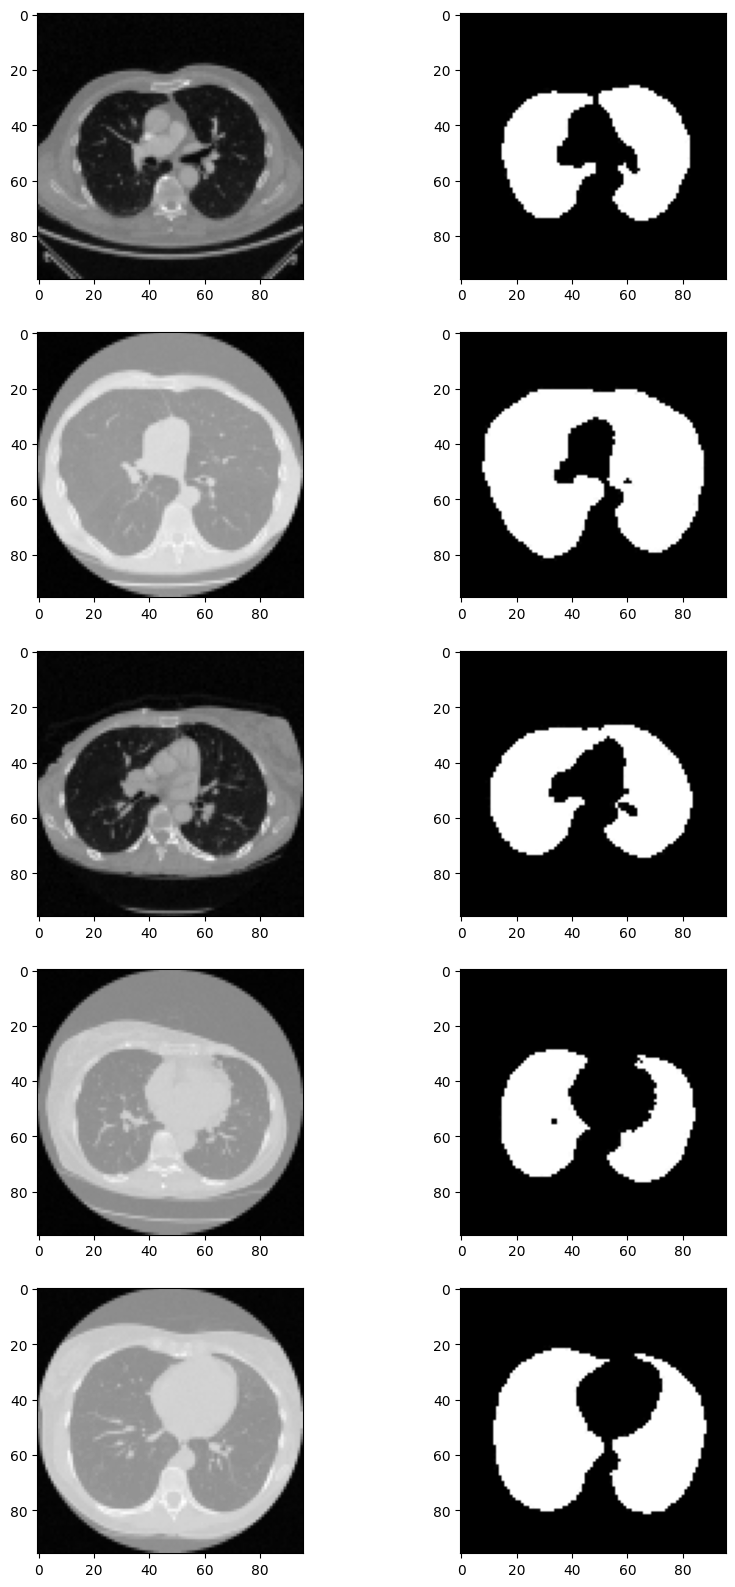

In [14]:
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    ax[i,0].imshow(imgs[i], cmap='gray')
    ax[i,1].imshow(masks[i], cmap='gray')
plt.show()

# **데이터 전처리**

AI 모델을 만들기 이전에 모델 학습에 도움을 줄 데이터 전처리를 살펴보겠습니다.  
이 과정을 통해 **AI 모델이 받아들이기 쉬운 형태로 데이터를 가공** 하여 학습 성능을 올릴 수 있습니다.  


먼저, 위에서 본 이미지 데이터를 컴퓨터가 실제로 인식하는 숫자 데이터로 확인해보겠습니다.

array([[14, 17, 16, ..., 16, 17, 15],
       [16, 14, 17, ..., 16, 14, 16],
       [15, 15, 14, ..., 16, 17, 15],
       ...,
       [14, 15, 16, ..., 16, 15, 15],
       [14, 13, 17, ..., 18, 15, 16],
       [14, 16, 15, ..., 15, 15, 17]], dtype=uint8)
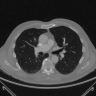

In [15]:
imgs[0]

범위가 넓고 단위가 큰 숫자들을 정규화하여 학습 성능을 높여봅시다.  


In [16]:
n_imgs = len(imgs)
imgs = np.reshape(imgs, (n_imgs, -1))
imgs_t = np.transpose(imgs, (1,0))
imgs_t_norm = (imgs_t - np.mean(imgs_t, axis=0)) / np.std(imgs_t, axis=0)
imgs = np.transpose(imgs_t_norm, (1,0))
imgs = np.reshape(imgs, (n_imgs, IMG_HEIGHT, IMG_WIDTH))

다시 값을 확인해 봅시다.

In [17]:
imgs[0]

array([[-0.95900571, -0.89648266, -0.91732367, ..., -0.91732367,
        -0.89648266, -0.93816469],
       [-0.91732367, -0.95900571, -0.89648266, ..., -0.91732367,
        -0.95900571, -0.91732367],
       [-0.93816469, -0.93816469, -0.95900571, ..., -0.91732367,
        -0.89648266, -0.93816469],
       ...,
       [-0.95900571, -0.93816469, -0.91732367, ..., -0.91732367,
        -0.93816469, -0.93816469],
       [-0.95900571, -0.97984673, -0.89648266, ..., -0.87564164,
        -0.93816469, -0.91732367],
       [-0.95900571, -0.91732367, -0.93816469, ..., -0.93816469,
        -0.93816469, -0.89648266]])

그 후 AI 모델에 넣을 수 있는 형태로 이미지 형태를 변형해 보겠습니다.

In [18]:
print('변경 전 형태: ', np.shape(imgs))
imgs = imgs[:,:,:,np.newaxis]
masks = masks[:,:,:,np.newaxis]
pred_masks = pred_masks[:,:,:,np.newaxis]
print('변경 후 형태: ', np.shape(imgs))
print('masks 변경 후 형태: ', np.shape(masks))

변경 전 형태:  (263, 96, 96)
변경 후 형태:  (263, 96, 96, 1)
masks 변경 후 형태:  (263, 96, 96, 1)


마지막으로, 데이터를 학습용 데이터와 검증용 데이터로 나누어 봅시다.  
**학습용 데이터**는 실제로 **모델 학습에 사용** 되는 데이터이고,  
**검증용 데이터**는 학습에 사용하지 않고 학습이 잘 이뤄지는 지 **성능 확인하는 용도**로 사용합니다.

In [19]:
imgs_train, imgs_val, masks_train, masks_val = train_test_split(imgs, masks, test_size=VAL_RATIO)
print('훈련 데이터 개수: ', len(imgs_train))
print('검증 데이터 개수: ', len(imgs_val))

훈련 데이터 개수:  210
검증 데이터 개수:  53


# 폐 영역 분리 AI 모델 만들기

Convolutional layer 함수 만들기

In [20]:
imgs_train.shape[1:]

(96, 96, 1)

In [21]:
input_layer = Input(shape=imgs_train.shape[1:])

inputs = Input(shape=imgs_train.shape[1:])

base = INIT_FILTERS

conv1 = Conv2D(base, (3, 3), activation='relu', padding='same')(inputs)
conv1 = BatchNormalization()(conv1)
conv1 = Activation('relu')(conv1)
conv1 = Conv2D(base, (3, 3), activation=None, padding='same')(conv1)
conv1 = BatchNormalization()(conv1)
conv1 = Activation('relu')(conv1)
pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

base = base * 2
conv2 = Conv2D(base, (3, 3), activation=None, padding='same')(pool1)
conv2 = BatchNormalization()(conv2)
conv2 = Activation('relu')(conv2)
conv2 = Conv2D(base, (3, 3), activation=None, padding='same')(conv2)
conv2 = BatchNormalization()(conv2)
conv2 = Activation('relu')(conv2)
pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

base = base * 2
conv3 = Conv2D(base, (3, 3), activation=None, padding='same')(pool2)
conv3 = BatchNormalization()(conv3)
conv3 = Activation('relu')(conv3)
conv3 = Conv2D(base, (3, 3), activation=None, padding='same')(conv3)
conv3 = BatchNormalization()(conv3)
conv3 = Activation('relu')(conv3)
pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

base = base * 2
conv4 = Conv2D(base, (3, 3), activation=None, padding='same')(pool3)
conv4 = BatchNormalization()(conv4)
conv4 = Activation('relu')(conv4)
conv4 = Conv2D(base, (3, 3), activation=None, padding='same')(conv4)
conv4 = BatchNormalization()(conv4)
conv4 = Activation('relu')(conv4)
pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

base = base * 2
conv5 = Conv2D(base, (3, 3), activation=None, padding='same')(pool4)
conv5 = BatchNormalization()(conv5)
conv5 = Activation('relu')(conv5)
conv5 = Conv2D(base, (3, 3), activation=None, padding='same')(conv5)
conv5 = BatchNormalization()(conv5)
conv5 = Activation('relu')(conv5)

base = int(base / 2)
up6 = concatenate([Conv2DTranspose(base, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)

conv6 = Conv2D(base, (3, 3), activation=None, padding='same')(up6)
conv6 = BatchNormalization()(conv6)
conv6 = Activation('relu')(conv6)
conv6 = Conv2D(base, (3, 3), activation=None, padding='same')(conv6)
conv6 = BatchNormalization()(conv6)
conv6 = Activation('relu')(conv6)

base = int(base / 2)
up7 = concatenate([Conv2DTranspose(base, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
conv7 = Conv2D(base, (3, 3), activation=None, padding='same')(up7)
conv7 = BatchNormalization()(conv7)
conv7 = Activation('relu')(conv7)
conv7 = Conv2D(base, (3, 3), activation=None, padding='same')(conv7)
conv7 = BatchNormalization()(conv7)
conv7 = Activation('relu')(conv7)

base = int(base / 2)
up8 = concatenate([Conv2DTranspose(base, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
conv8 = Conv2D(base, (3, 3), activation=None, padding='same')(up8)
conv8 = BatchNormalization()(conv8)
conv8 = Activation('relu')(conv8)
conv8 = Conv2D(base, (3, 3), activation=None, padding='same')(conv8)
conv8 = BatchNormalization()(conv8)
conv8 = Activation('relu')(conv8)

base = int(base / 2)
up9 = concatenate([Conv2DTranspose(base, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
conv9 = Conv2D(base, (3, 3), activation=None, padding='same')(up9)
conv9 = BatchNormalization()(conv9)
conv9 = Activation('relu')(conv9)
conv9 = Conv2D(base, (3, 3), activation=None, padding='same')(conv9)
conv9 = BatchNormalization()(conv9)
conv9 = Activation('relu')(conv9)

conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9) # 안되면 softmax

model = Model(inputs=inputs, outputs=conv10)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 96, 96, 32)           320       ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 96, 96, 32)           128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 96, 96, 32)           0         ['batch_normalization[0][0

# 미리 훈련시킨 AI 모델 파일 불러오기

AI 모델을 처음부터 훈련시켜도 되지만,  
미리 훈련시킨 모델 파일이 있는 경우 불러와서 훈련시킬 수도 있습니다.

In [22]:
# model.load_weights('lung_seg1.h5')

# AI 모델 옵션 설정하기

AI 모델을 만든 후 여러가지 훈련 옵션을 설정할 수 있습니다.  
학습률(Learning_rate) 과 손실함수(Loss function), 정확도 기준(Dice_score) 등을 설정해 봅시다.

먼저 정확도 기준으로 Dice score 를 살펴봅시다.  

In [23]:
 def dice_score(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

옵션은 complie 을 통해 설정할 수 있습니다.  
모델의 값을 학습시키는 **Optimizer** 는 **Adam** 을 사용하고,  
정답 레이블과 예측값 사이의 차이를 계산하는 **손실 함수**는 **Cross entropy** 를 사용했습니다.   
마지막으로 **정확도 판단 기준**으로는 위에서 만든 **Dice score** 를 사용합니다.

In [24]:
model.compile(optimizer=Adam(LEARNING_RATE), loss='binary_crossentropy', metrics=[dice_score])

추가적으로 AI 모델 훈련 파일을 lung.h5 라는 파일로 저장해 다음에 사용할 수 있도록 했고,  
학습이 진행될 수록 학습률(Learning_rate)를 감소시켜 세밀한 조정이 가능하게 했습니다.

In [25]:
weight_saver = ModelCheckpoint('./lung_seg1.h5', monitor='val_dice_score', save_best_only=True, save_weights_only=True)
decayed_lr = LearningRateScheduler(lambda x: LEARNING_RATE * DECAY_RATE ** x)

# AI 모델 훈련하기

이렇게 준비한 AI 모델을 fit 함수를 이용해 훈련시킬 수 있습니다.

In [26]:
history = model.fit(imgs_train, masks_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(imgs_val, masks_val),
                    shuffle=True,
                    verbose=2,
                    callbacks=[weight_saver, decayed_lr])

Epoch 1/20
42/42 - 20s - loss: 0.2590 - dice_score: 0.6494 - val_loss: 0.5438 - val_dice_score: 0.4027 - lr: 2.0000e-04 - 20s/epoch - 471ms/step
Epoch 2/20
42/42 - 1s - loss: 0.1063 - dice_score: 0.8234 - val_loss: 0.3277 - val_dice_score: 0.5978 - lr: 1.8000e-04 - 755ms/epoch - 18ms/step
Epoch 3/20
42/42 - 1s - loss: 0.0881 - dice_score: 0.8492 - val_loss: 0.3310 - val_dice_score: 0.5490 - lr: 1.6200e-04 - 758ms/epoch - 18ms/step
Epoch 4/20
42/42 - 1s - loss: 0.0785 - dice_score: 0.8637 - val_loss: 0.2383 - val_dice_score: 0.6709 - lr: 1.4580e-04 - 730ms/epoch - 17ms/step
Epoch 5/20
42/42 - 1s - loss: 0.0720 - dice_score: 0.8739 - val_loss: 0.2012 - val_dice_score: 0.7255 - lr: 1.3122e-04 - 739ms/epoch - 18ms/step
Epoch 6/20
42/42 - 1s - loss: 0.0678 - dice_score: 0.8802 - val_loss: 0.1972 - val_dice_score: 0.7419 - lr: 1.1810e-04 - 730ms/epoch - 17ms/step
Epoch 7/20
42/42 - 1s - loss: 0.0631 - dice_score: 0.8888 - val_loss: 0.2646 - val_dice_score: 0.6738 - lr: 1.0629e-04 - 716ms/epo

# 훈련 결과 확인하기

훈련 결과를 한 눈에 확인할 수 있는 그래프를 만들어 보겠습니다.

먼저 그래프의 y축에 사용할 값들을 history 항목에서 추출해 봅시다.

In [27]:
dice_score = history.history['dice_score']
val_dice_score = history.history['val_dice_score']
loss = history.history['loss']
val_loss = history.history['val_loss']

다음으로 그래프의 x축 값으로 사용할 epoch 을 뽑아 보겠습니다.

In [28]:
epochs = range(len(dice_score))

각 값들을 확인해볼까요?

In [29]:
dice_score

[0.6493868827819824,
 0.8234372735023499,
 0.8491823077201843,
 0.8637040257453918,
 0.873869776725769,
 0.880181610584259,
 0.8888041973114014,
 0.8944414258003235,
 0.8986446857452393,
 0.9034704566001892,
 0.9072039723396301,
 0.9117386341094971,
 0.9134745001792908,
 0.9160624742507935,
 0.9196844696998596,
 0.9215174317359924,
 0.9218260645866394,
 0.9248293042182922,
 0.925812304019928,
 0.9272968769073486]

In [30]:
val_dice_score

[0.4026931822299957,
 0.5977548956871033,
 0.5489893555641174,
 0.6709436178207397,
 0.7254539132118225,
 0.7419271469116211,
 0.6737968325614929,
 0.8704714179039001,
 0.8805023431777954,
 0.8947039246559143,
 0.9082918763160706,
 0.9113208651542664,
 0.916910707950592,
 0.9211764931678772,
 0.920902669429779,
 0.9241575598716736,
 0.9258880615234375,
 0.9257833957672119,
 0.9272201061248779,
 0.9287697076797485]

In [31]:
loss

[0.2589591443538666,
 0.10627447068691254,
 0.08808000385761261,
 0.07848228514194489,
 0.07202131301164627,
 0.06777221709489822,
 0.06308737397193909,
 0.0593951940536499,
 0.05675023794174194,
 0.0536901019513607,
 0.05103385075926781,
 0.04846852645277977,
 0.04703707993030548,
 0.04532056674361229,
 0.043629083782434464,
 0.04240527004003525,
 0.04175953567028046,
 0.04039264842867851,
 0.0395936518907547,
 0.03875156119465828]

In [32]:
val_loss

[0.5437526106834412,
 0.3277210593223572,
 0.3310072124004364,
 0.2382664531469345,
 0.20117489993572235,
 0.19717171788215637,
 0.2646157145500183,
 0.0847683846950531,
 0.07515929639339447,
 0.06291650235652924,
 0.05487755686044693,
 0.05303322896361351,
 0.049878962337970734,
 0.0482868030667305,
 0.047362953424453735,
 0.045821141451597214,
 0.04513479769229889,
 0.04510800167918205,
 0.04445738345384598,
 0.043990813195705414]

이 값들을 이용해 그래프를 만들어 보겠습니다.  

먼저 정확도 그래프를 그려볼까요?

<ipython-input-33-45962a1c004e>:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, dice_score, 'b', color='blue', label='Training score')
<ipython-input-33-45962a1c004e>:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_dice_score, 'b', color='red', label='Validation score')


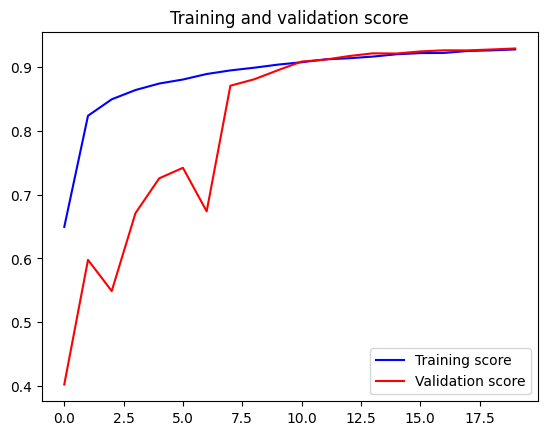

In [33]:
plt.plot(epochs, dice_score, 'b', color='blue', label='Training score')
plt.plot(epochs, val_dice_score, 'b', color='red', label='Validation score')
plt.title('Training and validation score')
plt.legend()
plt.show()

다음으로 손실 그래프를 살펴보겠습니다.

<ipython-input-34-cbd9e51137d7>:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', color='blue', label='Training loss')
<ipython-input-34-cbd9e51137d7>:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', color='red', label='Validation loss')


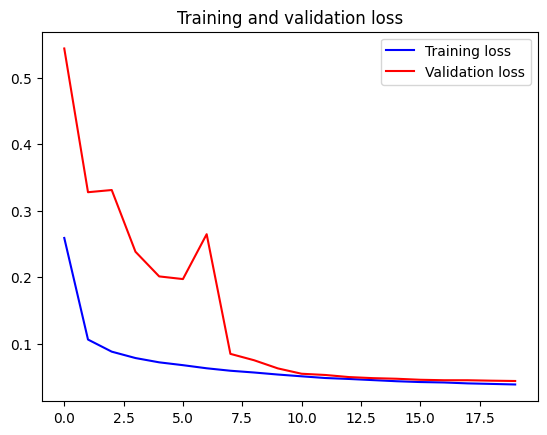

In [34]:
plt.plot(epochs, loss, 'b', color='blue', label='Training loss')
plt.plot(epochs, val_loss, 'b', color='red', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# 이미지로 결과 확인하기

마지막으로 AI 모델이 실제로 폐 영역을 잘 분리하는지 이미지로 결과를 확인해 보겠습니다.

1/1 [==============================] - 0s 23ms/step


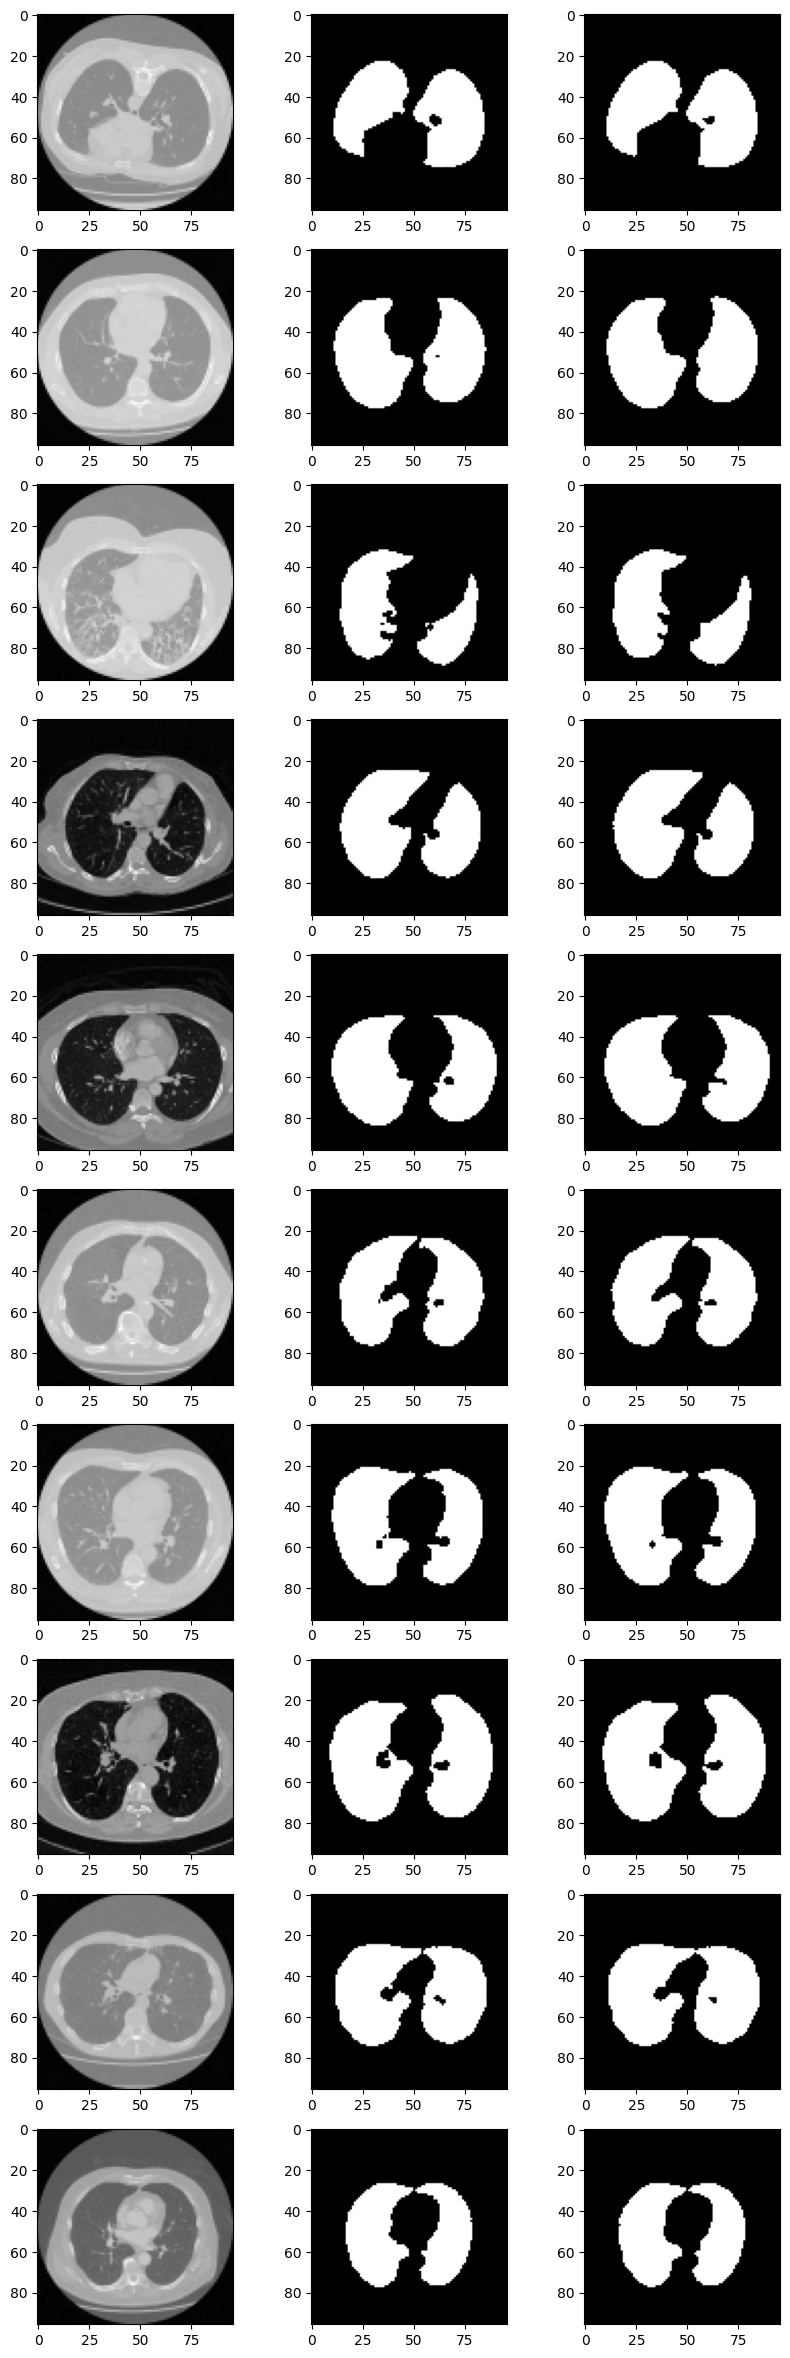

In [35]:
fix, ax = plt.subplots(10, 3, figsize=(10,30))
for i in range(10):
    pred = model.predict(imgs_train[i][np.newaxis, :, : ,:])
    mask = (pred >= 0.5).astype(np.uint8)
    ax[i, 0].imshow(imgs_train[i, :, :, 0], cmap='gray')
    ax[i, 1].imshow(masks_train[i, :, :, 0], cmap='gray')
    ax[i, 2].imshow(mask[0, :, :, 0], cmap='gray')
plt.show()

In [36]:
len(imgs_val)

53

In [37]:
recall_list = []
precision_list = []
acc_list = []
dice_list = []

for i in range(10):
    seg1 =  pred_masks[i]
    gt1 = masks_train[i]

    seg1_n = seg1 == 0
    seg1_t = seg1 == 1

    gt1_n = gt1 == 0
    gt1_t = gt1 == 1

    tp = np.sum(seg1_t&gt1_t)

    fp = np.sum(seg1_t&gt1_n)

    tn = np.sum(seg1_n&gt1_n)

    fn = np.sum(gt1_t&seg1_n)

    recall = tp / (tp + fn)
    recall_list.append(recall)

    precision = tp / (tp+fp)
    precision_list.append(precision)

    acc = (tp + tn) / (tp + tn + fp + fn)
    acc_list.append(acc)

    dice = (2*tp) / (2*tp + fp + fn)
    dice_list.append(dice)

recall_list = np.array(recall_list)
recall_list = recall_list[~np.isnan(recall_list)]
precision_list = np.array(precision_list)
precision_list = precision_list[~np.isnan(precision_list)]
acc_list = np.array(acc_list)
acc_list = acc_list[~np.isnan(acc_list)]
dice_list = np.array(dice_list)
dice_list = dice_list[~np.isnan(dice_list)]
print('Recall : ', np.mean(recall_list))
print('Precision : ', np.mean(precision_list))
print('Accuracy : ', np.mean(acc_list))
print('DSC : ', np.mean(dice_list))
print('-'*40)
print('Recall : ', np.std(recall_list))
print('Precision : ', np.std(precision_list))
print('Accuracy : ', np.std(acc_list))
print('DSC : ', np.std(dice_list))

Recall :  0.7725444926635806
Precision :  0.7908753976272681
Accuracy :  0.8900248142098377
DSC :  0.7756376886951368
----------------------------------------
Recall :  0.1177817772126852
Precision :  0.12028993792618889
Accuracy :  0.04999725015371977
DSC :  0.09611839113398016


In [38]:
fix, ax = plt.subplots(53, 3, figsize=(10,160))
for i in range(53):
    pred = model.predict(imgs_val[i][np.newaxis, :, : ,:])
    mask = (pred >= 0.5).astype(np.uint8)
    ax[i, 0].imshow(imgs_val[i, :, :, 0], cmap='gray')
    ax[i, 1].imshow(masks_val[i, :, :, 0], cmap='gray')
    ax[i, 2].imshow(mask[0, :, :, 0], cmap='gray')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [39]:
recall_list = []
precision_list = []
acc_list = []
dice_list = []

for i in range(len(imgs_val)):
    seg1 =  preds_mask[i]
    gt1 = masks_val[i]

    seg1_n = seg1 == 0
    seg1_t = seg1 == 1

    gt1_n = gt1 == 0
    gt1_t = gt1 == 1

    tp = np.sum(seg1_t&gt1_t)

    fp = np.sum(seg1_t&gt1_n)

    tn = np.sum(seg1_n&gt1_n)

    fn = np.sum(gt1_t&seg1_n)

    recall = tp / (tp + fn)
    recall_list.append(recall)

    precision = tp / (tp+fp)
    precision_list.append(precision)

    acc = (tp + tn) / (tp + tn + fp + fn)
    acc_list.append(acc)

    dice = (2*tp) / (2*tp + fp + fn)
    dice_list.append(dice)

recall_list = np.array(recall_list)
recall_list = recall_list[~np.isnan(recall_list)]
precision_list = np.array(precision_list)
precision_list = precision_list[~np.isnan(precision_list)]
acc_list = np.array(acc_list)
acc_list = acc_list[~np.isnan(acc_list)]
dice_list = np.array(dice_list)
dice_list = dice_list[~np.isnan(dice_list)]
print('Recall : ', np.mean(recall_list))
print('Precision : ', np.mean(precision_list))
print('Accuracy : ', np.mean(acc_list))
print('DSC : ', np.mean(dice_list))
print('-'*40)
print('Recall : ', np.std(recall_list))
print('Precision : ', np.std(precision_list))
print('Accuracy : ', np.std(acc_list))
print('DSC : ', np.std(dice_list))

NameError: name 'preds_mask' is not defined